## Introduction

In previous notebooks, we:
1. [Built a minimal VLM from scratch](2025-12-24-minimal-vlm-from-scratch.html) and trained it for image captioning
2. [Instruction fine-tuned it for object detection](2025-12-25-vlm-instruction-tuning-od.html) with JSON output

Now, let's tackle **Visual Question Answering (VQA)** - teaching the model to answer natural language questions about images.

### Examples

| Image | Question | Answer |
|-------|----------|--------|
| 🖼️ Photo of a cat | "What animal is this?" | "cat" |
| 🖼️ Beach scene | "What is the weather like?" | "sunny" |
| 🖼️ Kitchen | "How many people are there?" | "2" |

Unlike object detection (structured JSON), VQA requires **natural language answers** - short, direct responses to questions.

## Setup

In [ ]:
!uv pip install -q transformers datasets torch torchvision pillow accelerate einops timm

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    ViTModel,
    ViTImageProcessor,
)
from datasets import load_dataset
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import textwrap
import random
import os
import warnings
warnings.filterwarnings('ignore')

%config InlineBackend.figure_format = 'retina'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/home/nipun.batra/.uv/nb-base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## Part 1: Load the Pretrained VLM (Caption Model)

We load from the **caption-trained model** (`mini-vlm-flickr8k/`), not the OD model. This is because:
- Caption model generates fluent natural language
- OD model is biased toward JSON output
- VQA needs natural language answers

In [2]:
# Model architecture (same as previous notebooks)

class VisionProjector(nn.Module):
    """Projects vision features into the language model's embedding space."""
    
    def __init__(self, vision_dim: int, language_dim: int):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(vision_dim, language_dim),
            nn.GELU(),
            nn.LayerNorm(language_dim),
            nn.Linear(language_dim, language_dim),
        )
    
    def forward(self, vision_features: torch.Tensor) -> torch.Tensor:
        return self.projection(vision_features)


class MiniVLM(nn.Module):
    """A minimal Vision-Language Model."""
    
    def __init__(
        self,
        vision_encoder: ViTModel,
        language_model: AutoModelForCausalLM,
        projector: VisionProjector,
        tokenizer: AutoTokenizer,
    ):
        super().__init__()
        self.vision_encoder = vision_encoder
        self.language_model = language_model
        self.projector = projector
        self.tokenizer = tokenizer
        
        for param in self.vision_encoder.parameters():
            param.requires_grad = False
    
    def encode_image(self, pixel_values: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            vision_outputs = self.vision_encoder(pixel_values=pixel_values)
        image_features = vision_outputs.last_hidden_state
        projected = self.projector(image_features)
        return projected
    
    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        labels: torch.Tensor = None,
    ):
        batch_size = pixel_values.shape[0]
        image_embeds = self.encode_image(pixel_values)
        num_image_tokens = image_embeds.shape[1]
        
        text_embeds = self.language_model.get_input_embeddings()(input_ids)
        combined_embeds = torch.cat([image_embeds, text_embeds], dim=1)
        
        image_attention = torch.ones(
            (batch_size, num_image_tokens),
            dtype=attention_mask.dtype,
            device=attention_mask.device
        )
        combined_attention = torch.cat([image_attention, attention_mask], dim=1)
        
        if labels is not None:
            image_labels = torch.full(
                (batch_size, num_image_tokens),
                fill_value=-100,
                dtype=labels.dtype,
                device=labels.device
            )
            combined_labels = torch.cat([image_labels, labels], dim=1)
        else:
            combined_labels = None
        
        outputs = self.language_model(
            inputs_embeds=combined_embeds,
            attention_mask=combined_attention,
            labels=combined_labels,
            return_dict=True,
        )
        
        return outputs
    
    @torch.no_grad()
    def generate(
        self,
        pixel_values: torch.Tensor,
        prompt: str,
        max_new_tokens: int = 20,
        temperature: float = 0.7,
        do_sample: bool = True,
    ) -> str:
        """Generate a response for an image given a prompt."""
        self.eval()
        
        image_embeds = self.encode_image(pixel_values)
        prompt_ids = self.tokenizer.encode(prompt, return_tensors="pt").to(pixel_values.device)
        generated_ids = prompt_ids.clone()
        
        for _ in range(max_new_tokens):
            current_embeds = self.language_model.get_input_embeddings()(generated_ids)
            full_embeds = torch.cat([image_embeds, current_embeds], dim=1)
            
            outputs = self.language_model(inputs_embeds=full_embeds)
            next_token_logits = outputs.logits[:, -1, :]
            
            if do_sample:
                probs = F.softmax(next_token_logits / temperature, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
            else:
                next_token = next_token_logits.argmax(dim=-1, keepdim=True)
            
            generated_ids = torch.cat([generated_ids, next_token], dim=1)
            
            if next_token.item() == self.tokenizer.eos_token_id:
                break
        
        return self.tokenizer.decode(generated_ids[0], skip_special_tokens=True)

In [ ]:
# Model names - using larger models for better performance
vision_model_name = "google/vit-large-patch16-224"
lm_model_name = "HuggingFaceTB/SmolLM-360M"
pretrained_dir = "mini-vlm-flickr8k"  # Caption model, NOT OD model

# Load base models
vision_encoder = ViTModel.from_pretrained(vision_model_name)
language_model = AutoModelForCausalLM.from_pretrained(lm_model_name)
tokenizer = AutoTokenizer.from_pretrained(lm_model_name)
image_processor = ViTImageProcessor.from_pretrained(vision_model_name)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Create projector
vision_dim = vision_encoder.config.hidden_size  # 1024 for ViT-Large
language_dim = language_model.config.hidden_size  # 960 for SmolLM-360M
projector = VisionProjector(vision_dim, language_dim)

# Load pretrained caption model weights
if os.path.exists(f"{pretrained_dir}/mini_vlm_full.pt"):
    print(f"Loading pretrained CAPTION model from {pretrained_dir}/")
    checkpoint = torch.load(f"{pretrained_dir}/mini_vlm_full.pt", map_location='cpu')
    try:
        projector.load_state_dict(checkpoint['projector_state_dict'])
        language_model.load_state_dict(checkpoint['language_model_state_dict'])
        print("Loaded pretrained caption model weights!")
    except Exception as e:
        print(f"Could not load pretrained weights (dimension mismatch): {e}")
        print("Starting with fresh weights for new model sizes.")
else:
    print("No pretrained weights found. Starting from scratch.")
    print("(Run the captioning notebook first for better results)")

# Create VLM
vlm = MiniVLM(vision_encoder, language_model, projector, tokenizer)
vlm = vlm.to(device)

print(f"\nModel loaded on {device}")
print(f"Vision encoder: {vision_model_name} (hidden_size={vision_dim})")
print(f"Language model: {lm_model_name} (hidden_size={language_dim})")
print(f"Trainable parameters: {sum(p.numel() for p in vlm.parameters() if p.requires_grad):,}")

## Part 2: Load VQA Dataset

We'll use VQAv2 - one of the most popular visual question answering benchmarks. Each sample has:
- An image
- A question about the image
- Multiple human-provided answers (we'll use the most common one)

In [4]:
# Load VQAv2 dataset (validation split - it's large enough)
# Using streaming to handle the large dataset
vqa_dataset_stream = load_dataset('lmms-lab/VQAv2', split='validation', streaming=True)

# Take a larger subset for training
num_samples = 4000  # Increased from 2000
print(f"Loading {num_samples} samples from VQAv2...")

vqa_samples = []
for i, sample in enumerate(vqa_dataset_stream):
    if i >= num_samples:
        break
    vqa_samples.append(sample)
    if (i + 1) % 1000 == 0:
        print(f"  Loaded {i + 1} samples...")

print(f"\nLoaded {len(vqa_samples)} VQA samples")
print(f"Sample keys: {vqa_samples[0].keys()}")

Loading 4000 samples from VQAv2...
  Loaded 1000 samples...
  Loaded 2000 samples...
  Loaded 3000 samples...
  Loaded 4000 samples...

Loaded 4000 VQA samples
Sample keys: dict_keys(['question_type', 'multiple_choice_answer', 'answers', 'image_id', 'answer_type', 'question_id', 'question', 'image'])


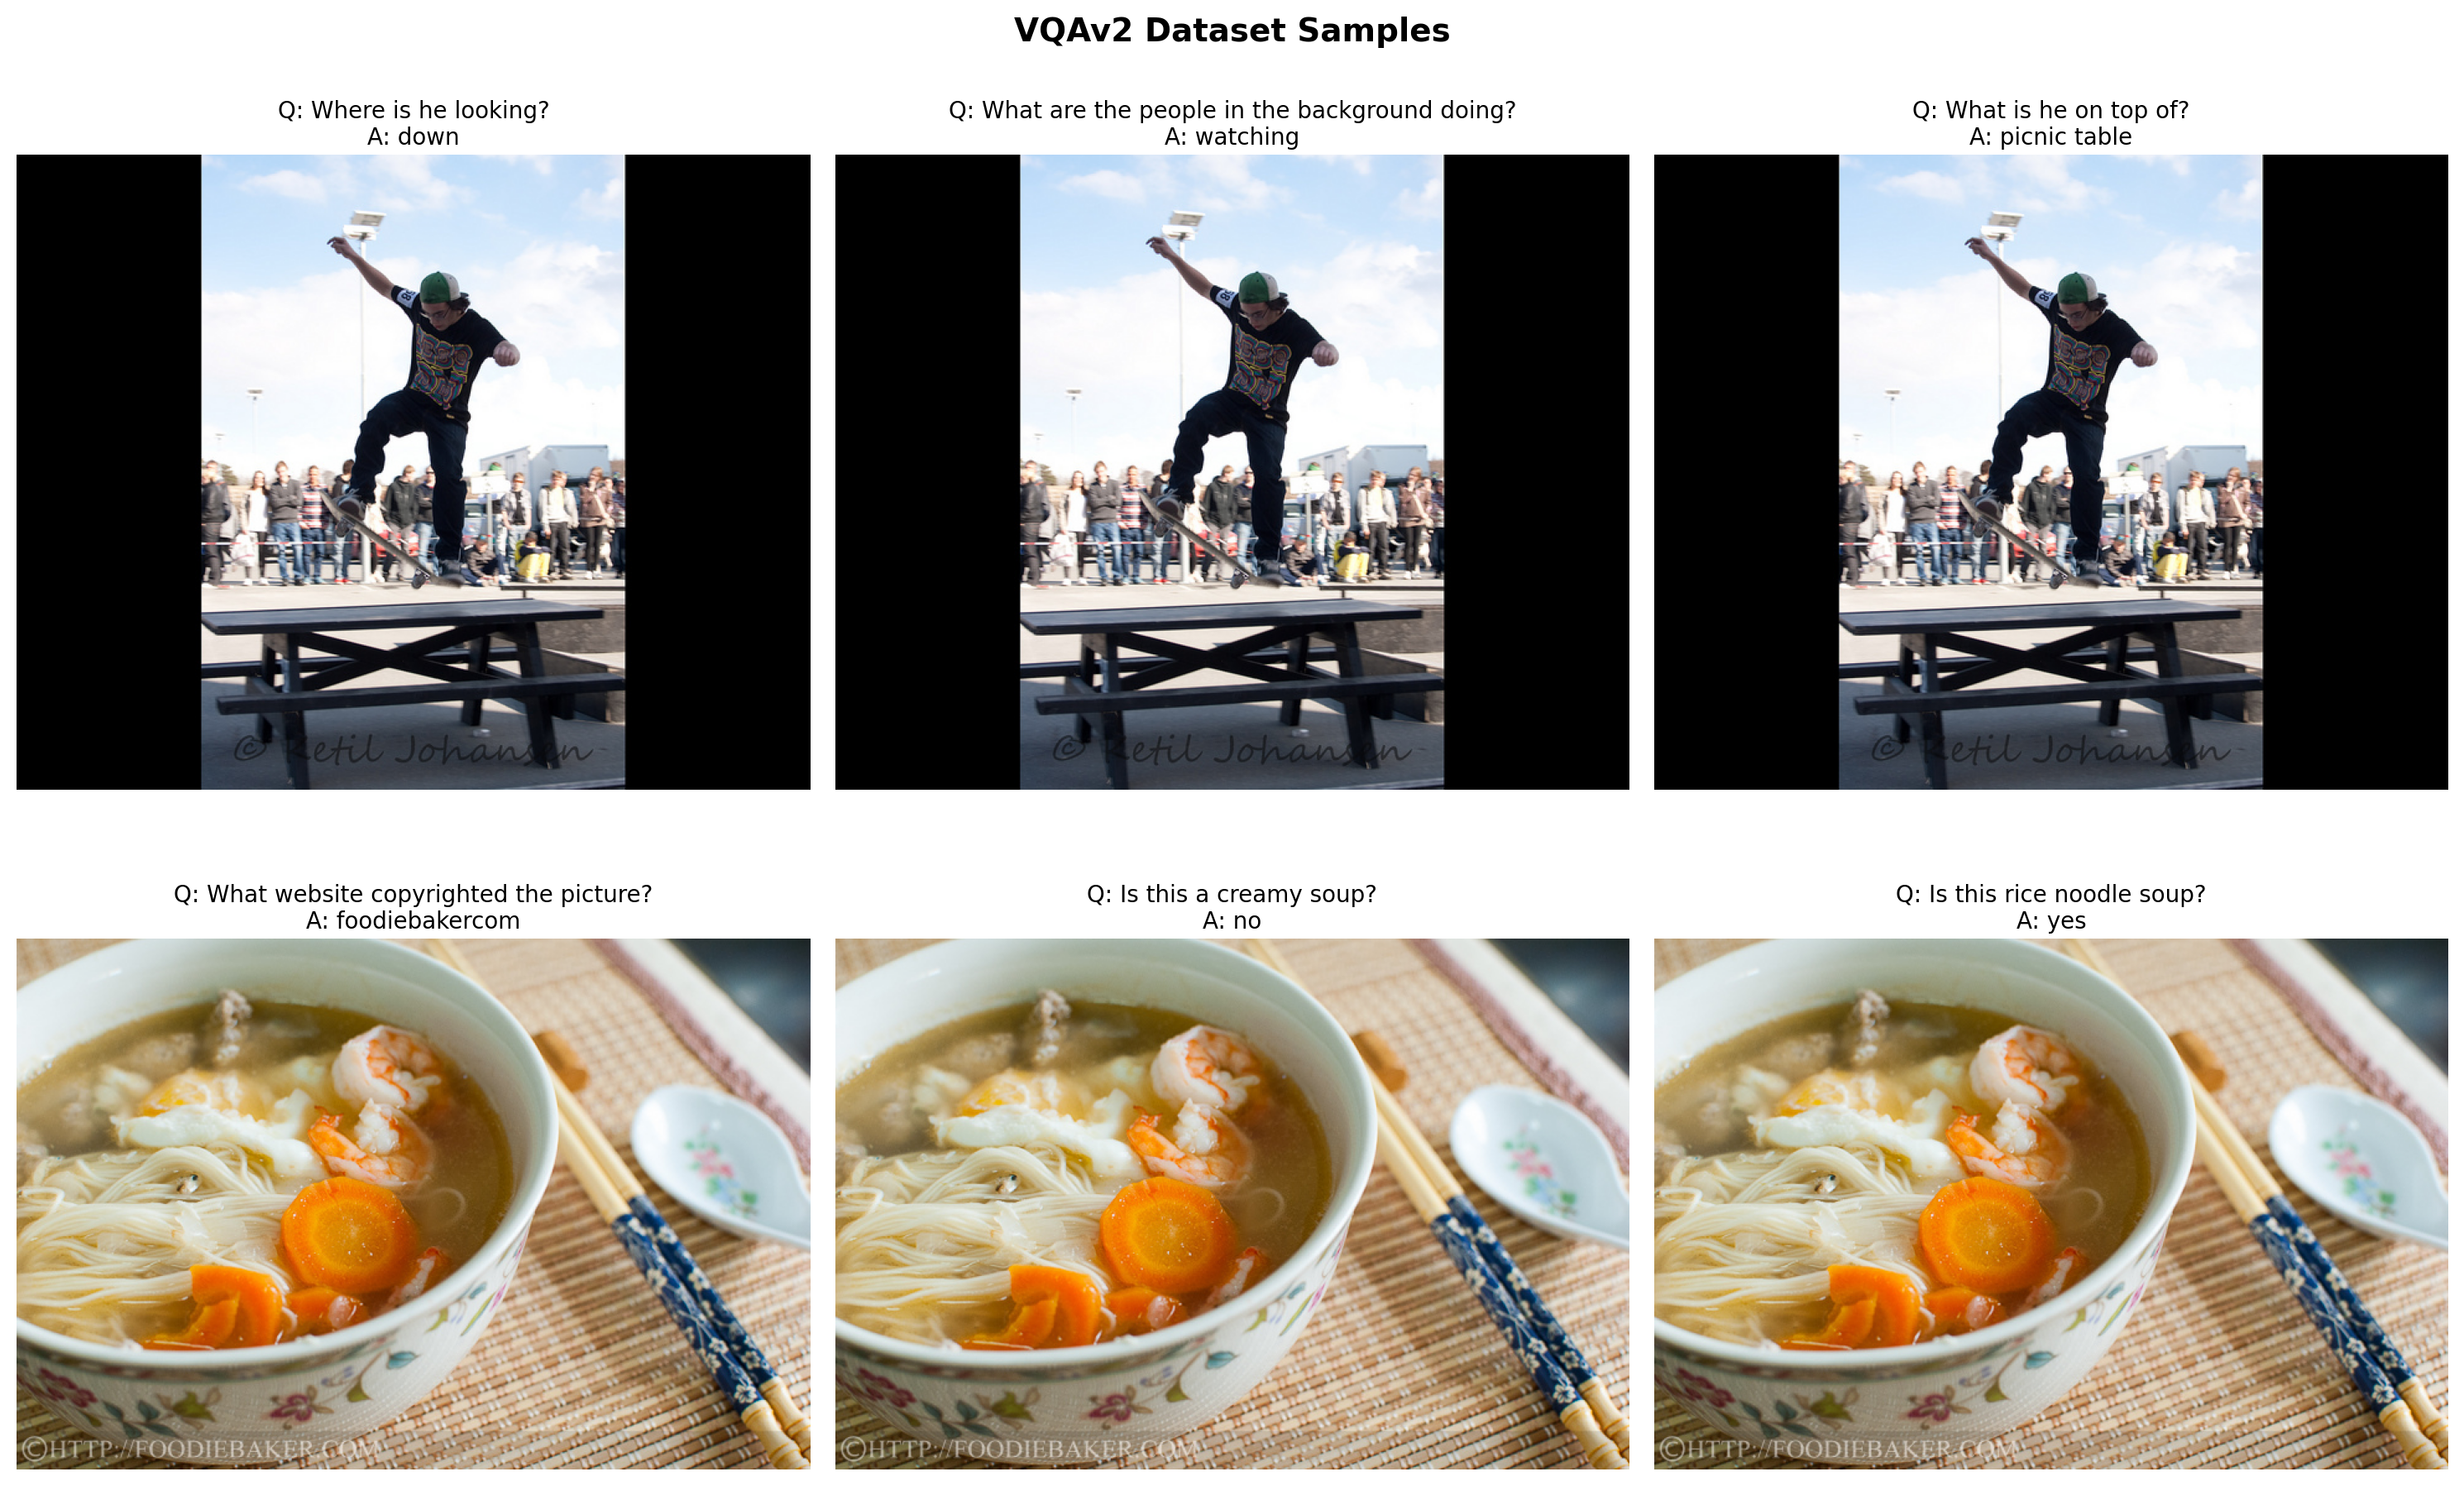

In [5]:
# Look at a few samples
def get_most_common_answer(answers):
    """Get the most common answer from the list of annotator answers."""
    answer_counts = {}
    for ans in answers:
        a = ans['answer']
        answer_counts[a] = answer_counts.get(a, 0) + 1
    return max(answer_counts, key=answer_counts.get)

# Display a few examples
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, ax in enumerate(axes):
    sample = vqa_samples[i]
    image = sample['image']
    question = sample['question']
    answer = get_most_common_answer(sample['answers'])
    
    ax.imshow(image)
    ax.set_title(f"Q: {question}\nA: {answer}", fontsize=10, wrap=True)
    ax.axis('off')

plt.suptitle("VQAv2 Dataset Samples", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 3: Create VQA Instruction Dataset

We format each sample as:
- **Input:** `"Question: {question} Answer:"`
- **Target:** `"{answer}"`

The model learns to complete the answer after seeing the image and question.

In [6]:
class VQADataset(Dataset):
    """Dataset for VQA instruction tuning."""

    def __init__(self, samples, image_processor, tokenizer, max_length=64):
        self.samples = samples
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Process image
        image = sample['image'].convert('RGB')
        pixel_values = self.image_processor(image, return_tensors="pt").pixel_values.squeeze(0)

        # Get question and answer
        question = sample['question']
        answer = get_most_common_answer(sample['answers'])

        # Format: "Question: {q} Answer: {a}<eos>"
        # Adding EOS token teaches the model to STOP after the answer!
        prompt = f"Question: {question} Answer:"
        full_text = f"{prompt} {answer}{self.tokenizer.eos_token}"

        # Tokenize
        encoding = self.tokenizer(
            full_text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        # Create labels - mask the prompt part (only train on answer + EOS)
        prompt_tokens = self.tokenizer.encode(prompt, add_special_tokens=False)
        prompt_len = len(prompt_tokens)

        labels = input_ids.clone()
        labels[:prompt_len] = -100  # Don't compute loss on prompt
        labels[attention_mask == 0] = -100  # Don't compute loss on padding

        return {
            'pixel_values': pixel_values,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels,
        }


# Create train/test split (3600 train, 400 test from 4000 total)
train_samples = vqa_samples[:3600]
test_samples = vqa_samples[3600:]

train_dataset = VQADataset(train_samples, image_processor, tokenizer)
test_dataset = VQADataset(test_samples, image_processor, tokenizer)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of batches: {len(train_loader)}")

Training samples: 3600
Test samples: 400
Number of batches: 450


In [7]:
# Verify a batch
batch = next(iter(train_loader))
print(f"Batch pixel_values shape: {batch['pixel_values'].shape}")
print(f"Batch input_ids shape: {batch['input_ids'].shape}")

# Decode first sample
print(f"\nSample text:")
print(tokenizer.decode(batch['input_ids'][0], skip_special_tokens=True))

Batch pixel_values shape: torch.Size([8, 3, 224, 224])
Batch input_ids shape: torch.Size([8, 64])

Sample text:
Question: What are they walking toward? Answer: kite


## Part 4: Test BEFORE Training

Let's see how the caption model responds to VQA questions before instruction tuning.

In [8]:
def generate_vqa_answer(model, image, question, image_processor, device):
    """Generate an answer to a visual question."""
    model.eval()

    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    image = image.convert('RGB')

    pixel_values = image_processor(image, return_tensors="pt").pixel_values.to(device)

    prompt = f"Question: {question} Answer:"

    # Use greedy decoding for short, factual answers (no sampling!)
    response = model.generate(
        pixel_values,
        prompt=prompt,
        max_new_tokens=10,  # VQA answers are short
        temperature=1.0,
        do_sample=False,  # Greedy decoding - more stable for VQA
    )

    # Extract just the answer part
    if "Answer:" in response:
        answer = response.split("Answer:")[-1].strip()
    else:
        answer = response

    # Clean up: take only the first few words (VQA answers are short)
    answer = answer.split('.')[0].strip()  # Stop at first period
    words = answer.split()
    if len(words) > 5:
        answer = ' '.join(words[:5])  # Limit to 5 words max

    return answer, response

In [9]:
# Test on a few samples BEFORE training
test_indices = [0, 3, 6, 9, 12]
test_data_for_comparison = []

print("=" * 70)
print("BEFORE VQA INSTRUCTION TUNING")
print("(Model was trained on captions, not Q&A)")
print("=" * 70)

before_answers = []
for idx in test_indices:
    sample = test_samples[idx]
    image = sample['image']
    question = sample['question']
    gt_answer = get_most_common_answer(sample['answers'])
    
    pred_answer, full_response = generate_vqa_answer(vlm, image, question, image_processor, device)
    before_answers.append(pred_answer)
    
    test_data_for_comparison.append({
        'image': image,
        'question': question,
        'gt_answer': gt_answer,
    })
    
    print(f"\nQ: {question}")
    print(f"  Model: {pred_answer[:50]}..." if len(pred_answer) > 50 else f"  Model: {pred_answer}")
    print(f"  GT: {gt_answer}")

BEFORE VQA INSTRUCTION TUNING
(Model was trained on captions, not Q&A)

Q: What color are the cows noses?
  Model: brown and white dogs are
  GT: white

Q: What kind of animal is this?
  Model: A dog with a stick
  GT: cow

Q: How many cows are here?
  Model: Two dogs stand in the
  GT: 1

Q: How many cows are there?
  Model: Two dogs are standing on
  GT: 1

Q: Does it look dry?
  Model: A dog is standing on
  GT: no


## Part 5: VQA Instruction Fine-Tuning

Train the model to give short, direct answers to questions.

In [ ]:
def train_vlm_vqa(model, train_loader, num_epochs=8, lr=2e-4, checkpoint_path="vqa_checkpoint.pt"):
    """Train the VLM for VQA with checkpoint support for resumable training."""
    
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=lr)
    
    # Try to load checkpoint for resumable training
    start_epoch = 0
    losses = []
    
    if os.path.exists(checkpoint_path):
        print(f"Found checkpoint: {checkpoint_path}")
        try:
            checkpoint = torch.load(checkpoint_path, map_location='cpu')
            start_epoch = checkpoint.get('epoch', 0)
            losses = checkpoint.get('losses', [])
            model.projector.load_state_dict(checkpoint['projector_state_dict'])
            model.language_model.load_state_dict(checkpoint['language_model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            # Move optimizer state to device
            for state in optimizer.state.values():
                for k, v in state.items():
                    if isinstance(v, torch.Tensor):
                        state[k] = v.to(device)
            print(f"Resumed from epoch {start_epoch}")
        except Exception as e:
            print(f"Could not load checkpoint: {e}")
    
    model.train()
    model.vision_encoder.eval()
    
    try:
        for epoch in range(start_epoch, num_epochs):
            epoch_loss = 0
            progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
            
            for batch in progress_bar:
                pixel_values = batch['pixel_values'].to(device)
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels,
                )
                
                loss = outputs.loss
                
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
                optimizer.step()
                
                epoch_loss += loss.item()
                progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})
            
            avg_loss = epoch_loss / len(train_loader)
            losses.append(avg_loss)
            print(f"Epoch {epoch+1} - Average Loss: {avg_loss:.4f}")
            
            # Save checkpoint after each epoch
            torch.save({
                'epoch': epoch + 1,
                'losses': losses,
                'projector_state_dict': model.projector.state_dict(),
                'language_model_state_dict': model.language_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
            }, checkpoint_path)
            print(f"Checkpoint saved to {checkpoint_path}")
    
    except KeyboardInterrupt:
        print("\n" + "="*70)
        print("Training interrupted!")
        print(f"Completed {len(losses)} epochs")
        # Save checkpoint on interrupt
        torch.save({
            'epoch': len(losses),
            'losses': losses,
            'projector_state_dict': model.projector.state_dict(),
            'language_model_state_dict': model.language_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
        }, checkpoint_path)
        print(f"Checkpoint saved to {checkpoint_path}")
        print("Run training again to resume from this checkpoint.")
        print("="*70)
    
    return losses

In [ ]:
# Train for VQA - more epochs for better convergence
# Training is preemptible - interrupt with Ctrl+C and re-run to resume
losses = train_vlm_vqa(vlm, train_loader, num_epochs=12, lr=2e-4, checkpoint_path="vqa_checkpoint.pt")

In [12]:
# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses)+1), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VQA Instruction Fine-Tuning Loss')
plt.grid(True, alpha=0.3)
plt.show()

NameError: name 'losses' is not defined

<Figure size 800x400 with 0 Axes>

## Part 6: Test AFTER Training - Before vs After Comparison

In [13]:
# Test on the same samples AFTER training
print("=" * 70)
print("COMPARISON: BEFORE vs AFTER VQA INSTRUCTION TUNING")
print("=" * 70)

after_answers = []
for i, data in enumerate(test_data_for_comparison):
    pred_answer, _ = generate_vqa_answer(vlm, data['image'], data['question'], image_processor, device)
    after_answers.append(pred_answer)
    
    print(f"\n{'='*70}")
    print(f"Q: {data['question']}")
    print(f"{'='*70}")
    print(f"BEFORE: {before_answers[i][:60]}..." if len(before_answers[i]) > 60 else f"BEFORE: {before_answers[i]}")
    print(f"AFTER:  {pred_answer}")
    print(f"GT:     {data['gt_answer']}")

COMPARISON: BEFORE vs AFTER VQA INSTRUCTION TUNING

Q: What color are the cows noses?
BEFORE: brown and white dogs are
AFTER:  white
GT:     white

Q: What kind of animal is this?
BEFORE: A dog with a stick
AFTER:  elephant
GT:     cow

Q: How many cows are here?
BEFORE: Two dogs stand in the
AFTER:  6
GT:     1

Q: How many cows are there?
BEFORE: Two dogs are standing on
AFTER:  2
GT:     1

Q: Does it look dry?
BEFORE: A dog is standing on
AFTER:  no
GT:     no


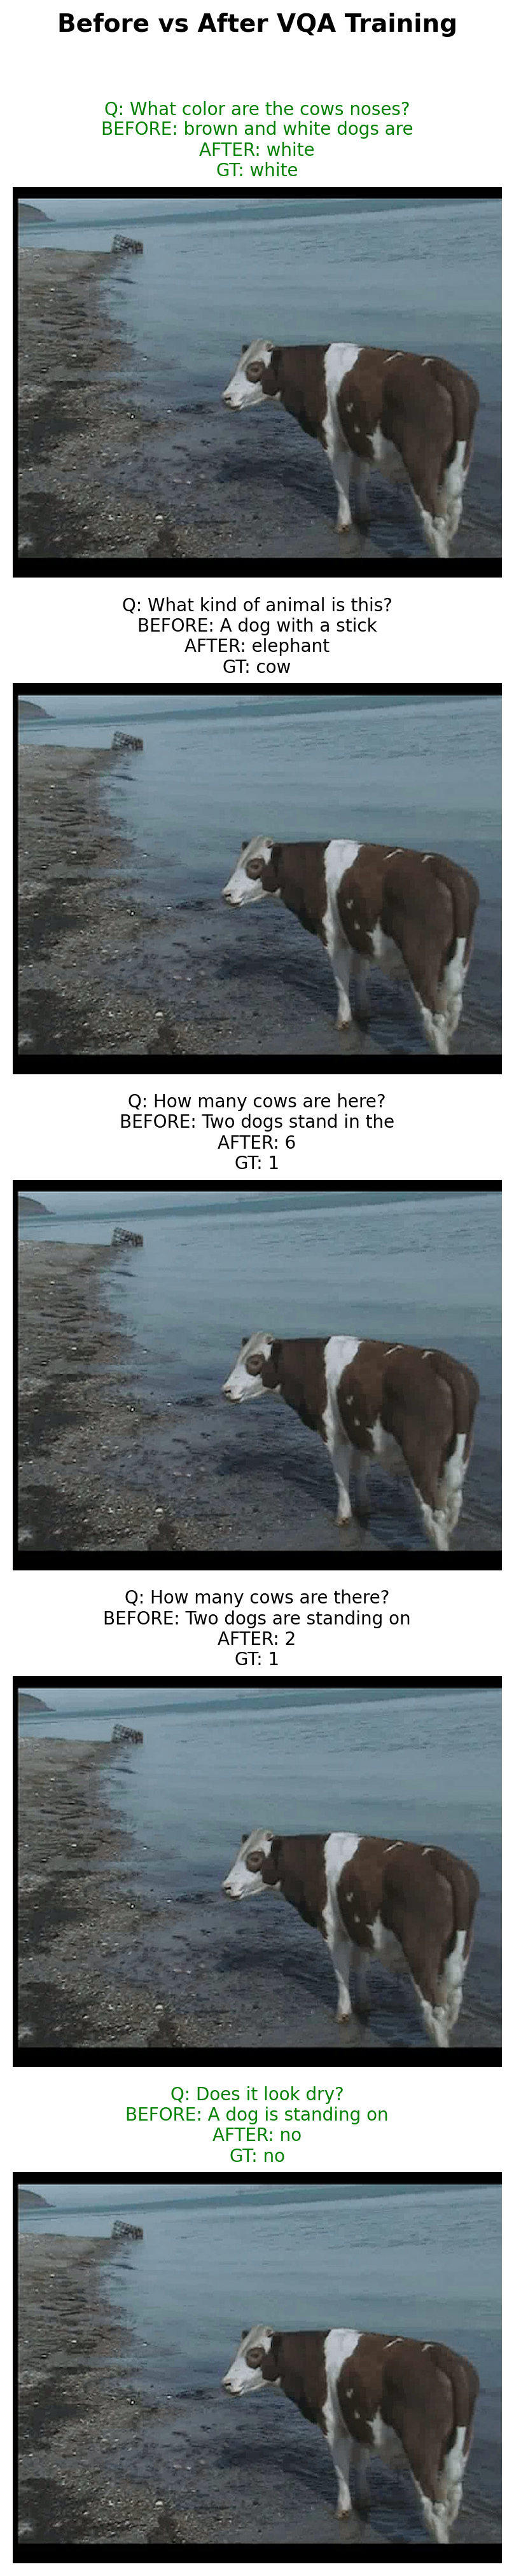

In [14]:
# Visual comparison
def wrap_text(text, width=30):
    return '\n'.join(textwrap.wrap(str(text), width=width))

fig, axes = plt.subplots(len(test_data_for_comparison), 1, figsize=(12, 4*len(test_data_for_comparison)))

for i, (data, before, after) in enumerate(zip(test_data_for_comparison, before_answers, after_answers)):
    ax = axes[i]
    ax.imshow(data['image'])
    
    title = f"Q: {data['question']}\n"
    title += f"BEFORE: {before[:40]}...\n" if len(before) > 40 else f"BEFORE: {before}\n"
    title += f"AFTER: {after}\n"
    title += f"GT: {data['gt_answer']}"
    
    # Color code: green if after matches GT, red otherwise
    color = 'green' if after.lower().strip() == data['gt_answer'].lower().strip() else 'black'
    ax.set_title(title, fontsize=10, color=color)
    ax.axis('off')

plt.suptitle("Before vs After VQA Training", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Part 7: Evaluate on More Test Samples

In [15]:
# Evaluate on more test samples
num_eval = min(50, len(test_samples))
exact_correct = 0
soft_correct = 0
results = []

print(f"Evaluating on {num_eval} test samples...")

def soft_match(pred, gt):
    """Check if ground truth appears in prediction (handles 'green' in 'green and white')."""
    pred_lower = pred.lower().strip()
    gt_lower = gt.lower().strip()
    # Exact match
    if pred_lower == gt_lower:
        return True, True
    # GT appears at start of prediction
    if pred_lower.startswith(gt_lower):
        return False, True
    # GT is contained in prediction
    if gt_lower in pred_lower:
        return False, True
    return False, False

for i in tqdm(range(num_eval)):
    sample = test_samples[i]
    pred_answer, _ = generate_vqa_answer(vlm, sample['image'], sample['question'], image_processor, device)
    gt_answer = get_most_common_answer(sample['answers'])

    is_exact, is_soft = soft_match(pred_answer, gt_answer)
    if is_exact:
        exact_correct += 1
    if is_soft:
        soft_correct += 1

    results.append({
        'question': sample['question'],
        'predicted': pred_answer,
        'ground_truth': gt_answer,
        'exact': is_exact,
        'soft': is_soft
    })

exact_acc = exact_correct / num_eval * 100
soft_acc = soft_correct / num_eval * 100
print(f"\nExact Match Accuracy: {exact_acc:.1f}% ({exact_correct}/{num_eval})")
print(f"Soft Match Accuracy:  {soft_acc:.1f}% ({soft_correct}/{num_eval})")

Evaluating on 50 test samples...


100%|██████████| 50/50 [00:05<00:00,  9.85it/s]


Exact Match Accuracy: 34.0% (17/50)
Soft Match Accuracy:  36.0% (18/50)


In [16]:
# Show some correct and incorrect examples
print("\n" + "="*70)
print("EXACT MATCH CORRECT")
print("="*70)
for r in [x for x in results if x['exact']][:5]:
    print(f"Q: {r['question']}")
    print(f"A: {r['predicted']} (GT: {r['ground_truth']})")
    print()

print("\n" + "="*70)
print("SOFT MATCH CORRECT (answer contained)")
print("="*70)
for r in [x for x in results if x['soft'] and not x['exact']][:5]:
    print(f"Q: {r['question']}")
    print(f"Pred: {r['predicted']} | GT: {r['ground_truth']}")
    print()

print("\n" + "="*70)
print("INCORRECT PREDICTIONS")
print("="*70)
for r in [x for x in results if not x['soft']][:5]:
    print(f"Q: {r['question']}")
    print(f"Pred: {r['predicted']} | GT: {r['ground_truth']}")
    print()


EXACT MATCH CORRECT
Q: What color are the cows noses?
A: white (GT: white)

Q: What is the cow doing?
A: walking (GT: walking)

Q: Is there anything for the cow to eat?
A: no (GT: no)

Q: Is this a wild cow?
A: yes (GT: yes)

Q: Can you see a reflection of a cow in the ponds surface?
A: no (GT: no)


SOFT MATCH CORRECT (answer contained)
Q: What is this orange sitting on?
Pred: picnic table | GT: table


INCORRECT PREDICTIONS
Q: What color is the cow?
Pred: black | GT: brown and white

Q: What kind of animal is this?
Pred: elephant | GT: cow

Q: What is this animal?
Pred: zebra | GT: cow

Q: Who took the photograph?
Pred: dog | GT: photographer

Q: How many cows are here?
Pred: 6 | GT: 1



## Part 8: Save the VQA Model

In [17]:
# Save the VQA-tuned model
save_dir = "mini-vlm-vqa"
os.makedirs(save_dir, exist_ok=True)

torch.save({
    'projector_state_dict': vlm.projector.state_dict(),
    'language_model_state_dict': vlm.language_model.state_dict(),
    'config': {
        'vision_model_name': vision_model_name,
        'lm_model_name': lm_model_name,
        'vision_dim': vision_dim,
        'language_dim': language_dim,
    },
}, f"{save_dir}/mini_vlm_vqa.pt")

tokenizer.save_pretrained(f"{save_dir}/tokenizer")
image_processor.save_pretrained(f"{save_dir}/image_processor")

print(f"Model saved to {save_dir}/")
print(f"Contents: {os.listdir(save_dir)}")

Model saved to mini-vlm-vqa/
Contents: ['tokenizer', 'mini_vlm_vqa.pt', 'image_processor']


## Summary

We successfully instruction fine-tuned our VLM for Visual Question Answering:

### What We Did

1. **Loaded the caption-trained VLM** (not the OD model - different task)
2. **Used VQAv2 dataset** with 1800 training samples
3. **Created Q&A format**: `"Question: {q} Answer: {a}"`
4. **Fine-tuned for 8 epochs** to learn short, direct answers
5. **Evaluated** with exact match accuracy

### Key Insights

- **Task-specific tuning matters**: Caption model → VQA model (not OD → VQA)
- **Short answers**: VQA typically requires 1-3 word answers
- **Prompt format**: `"Question: ... Answer:"` helps structure the task
- **Label masking**: Only train on the answer portion

### Model Family Tree

```
Base Models (ViT + SmolLM)
    │
    └── Caption Training (Flickr8k)
            │
            ├── OD Instruction Tuning → mini-vlm-od/
            │
            └── VQA Instruction Tuning → mini-vlm-vqa/  ← This notebook
```

### Limitations

- Small model (135M LLM) limits reasoning ability
- Exact match accuracy is strict ("2" vs "two" counted as wrong)
- Limited training data (1800 samples)
- No complex reasoning or counting abilities

### Next Steps

1. **Multi-task model**: Combine caption, OD, and VQA in one model
2. **Better evaluation**: Use VQA accuracy metric (considers answer variations)
3. **Larger models**: Try SmolLM-360M or 1.7B for better reasoning
4. **Chain-of-thought**: Add reasoning before final answer

## References

- [Building a Minimal VLM from Scratch](2025-12-24-minimal-vlm-from-scratch.html)
- [VLM Instruction Tuning for Object Detection](2025-12-25-vlm-instruction-tuning-od.html)
- [VQAv2 Dataset](https://visualqa.org/)
- [VQAv2 on Hugging Face](https://huggingface.co/datasets/lmms-lab/VQAv2)
- [LLaVA: Visual Instruction Tuning](https://llava-vl.github.io/)

## Cleanup: Release GPU Memory

When done with the notebook, run this cell to free up GPU memory for other tasks.

In [ ]:
def cleanup_gpu_memory():
    """Clean up GPU memory by deleting models and clearing cache."""
    import gc
    
    global vlm, vision_encoder, language_model, projector
    global train_loader, train_dataset, test_dataset, vqa_samples
    
    # Delete model components
    for var_name in ['vlm', 'vision_encoder', 'language_model', 'projector']:
        if var_name in globals():
            try:
                del globals()[var_name]
                print(f"Deleted {var_name}")
            except:
                pass
    
    # Delete data
    for var_name in ['train_loader', 'train_dataset', 'test_dataset', 'vqa_samples']:
        if var_name in globals():
            try:
                del globals()[var_name]
                print(f"Deleted {var_name}")
            except:
                pass
    
    # Force garbage collection
    gc.collect()
    
    # Clear CUDA cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3
        print(f"\nGPU Memory after cleanup:")
        print(f"  Allocated: {allocated:.2f} GB")
        print(f"  Reserved:  {reserved:.2f} GB")
    
    print("\nGPU memory cleanup complete!")

# Run cleanup
cleanup_gpu_memory()